# Baseline Model: Daily PM2.5 Prediction Using Lag Features and Seasonal Encoding
## Objective
This notebook builds an interpretable baseline model to predict daily PM2.5 using:
- Lagged PM2.5 values (previous day and previous week)
- Seasonal indicators (one-hot encoding)
Model performance is evaluated using:
- MAE
- RMSE
- R²
- MAPE

A time-based split is used to simulate real-world forecasting.

## 1. Import Required Libraries

In [4]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

## 2. Load Processed PM2.5 Dataset
The dataset contains daily aggregated PM2.5 values along with city and seasonal information.

In [13]:
df = pd.read_csv("../../data/master/PM25_2020 cleaned Master_20_23.csv")
df.head()

,City,Date,PM25,Year,Month,Season
0,Montréal,2020-01-01,4.333333333,2020,1,Winter
1,Montréal,2020-01-02,7.625,2020,1,Winter
2,Montréal,2020-01-03,10.75,2020,1,Winter
3,Montréal,2020-01-04,4.416666667,2020,1,Winter
4,Montréal,2020-01-05,3.833333333,2020,1,Winter


## 3. Data Preparation
- Convert Date to datetime
- Sort by City and Date
- Ensure correct chronological order for lag creation

In [22]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["City", "Date"]).reset_index(drop=True)

## Ensure PM25 is Numeric for Modeling
Although the dataset was cleaned earlier, we validate and enforce numeric data types to ensure compatibility with mathematical operations such as rolling averages.

In [28]:
df["PM25"] = df["PM25"].astype(str).str.strip()
df["PM25"] = pd.to_numeric(df["PM25"], errors="coerce")
print("Missing PM25 after conversion:", df["PM25"].isna().sum())

df[["City", "Date", "PM25"]].head()

Missing PM25 after conversion: 58794


,City,Date,PM25
0,Agassiz,2020-01-01,0.666667
1,Agassiz,2020-01-02,1.291667
2,Agassiz,2020-01-03,1.333333
3,Agassiz,2020-01-04,3.791667
4,Agassiz,2020-01-05,4.291667


## 4. Create Lag Features
We create:
- PM25_lag1 → Previous day
- PM25_lag7 → Previous week
- PM25_roll7_mean → 7-day rolling average

These capture short-term temporal dynamics.

In [32]:
df["PM25_lag1"] = df.groupby("City")["PM25"].shift(1)
df["PM25_lag7"] = df.groupby("City")["PM25"].shift(7)

df["PM25_roll7_mean"] = (
    df.groupby("City")["PM25"]
    .shift(1)
    .rolling(7)
    .mean()
    .reset_index(level=0, drop=True)
)

## 5. Encode Seasonal Variable (One-Hot Encoding)
Season is categorical, so we convert it to numerical format.
One category is dropped to avoid multicollinearity.

In [35]:
season_dummies = pd.get_dummies(df["Season"], prefix="Season", drop_first=True)
df = pd.concat([df, season_dummies], axis=1)

## 6. Prepare Final Modeling Dataset
- Select feature columns
- Drop rows with missing lag values
- Define X (features) and y (target)

In [38]:
feature_cols = ["PM25_lag1", "PM25_lag7", "PM25_roll7_mean"] + list(season_dummies.columns)
model_df = df.dropna(subset=feature_cols + ["PM25"])
X = model_df[feature_cols]
y = model_df["PM25"]
X.shape, y.shape

((258699, 6), (258699,))

## 7. Time-Based Train-Test Split
We split the dataset chronologically:
- First 80% → Training
- Last 20% → Testing
This prevents data leakage.

In [41]:
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:] 

## 8. Train Baseline Linear Regression Model

In [44]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 9. Model Evaluation

We evaluate using:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (Variance Explained)
- MAPE (Mean Absolute Percentage Error)

In [47]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape_value = mape(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")
print(f"MAPE : {mape_value:.2f}%")

MAE  : 2.808
RMSE : 7.284
R²   : 0.536
MAPE : 57.84%


### Interpretation of Baseline Model

The linear regression baseline explains approximately 53.6% of the variation in daily PM2.5 levels (R² = 0.536). 

The strongest predictor is the previous day's PM2.5 value, indicating strong temporal dependence in air pollution data. Seasonal effects also contribute to prediction, though their impact is smaller compared to short-term pollution trends.

Overall, the model captures general pollution patterns but slightly underestimates extreme spikes, suggesting potential nonlinear effects.

## 10. Naive Baseline Comparison

We compare with a naive approach:
Predict today’s PM2.5 = yesterday’s PM2.5.

In [50]:
naive_pred = X_test["PM25_lag1"]

naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
naive_r2 = r2_score(y_test, naive_pred)
naive_mape = mape(y_test, naive_pred)

print("Naive Baseline:")
print(f"MAE  : {naive_mae:.3f}")
print(f"RMSE : {naive_rmse:.3f}")
print(f"R²   : {naive_r2:.3f}")
print(f"MAPE : {naive_mape:.2f}%")

Naive Baseline:
MAE  : 2.988
RMSE : 7.885
R²   : 0.457
MAPE : 53.36%


### Interpretation of Naive Baseline

The naive approach, which predicts today's PM2.5 as yesterday’s value, explains 45.7% of variability (R² = 0.457). 

While this simple method performs reasonably well due to strong autocorrelation in pollution data, it is less accurate than the regression model. This confirms that incorporating seasonal indicators and additional lag features improves predictive performance.

## 11. Actual vs Predicted PM2.5 Values

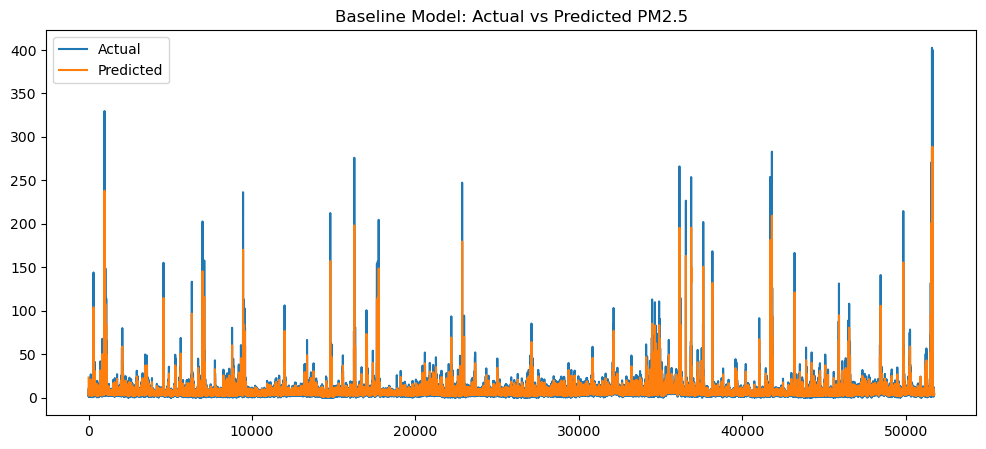

In [53]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Baseline Model: Actual vs Predicted PM2.5")
plt.show()

### Model Comparison Summary

Compared to the naive approach, the linear regression model reduces prediction error and increases explained variance. This supports the hypothesis that historical PM2.5 values and seasonal information significantly improve short-term forecasting accuracy.

## 12. Model Coefficient Interpretation

Linear regression allows direct interpretation of feature influence.

In [63]:
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

coef_df

,Feature,Coefficient
0,PM25_lag1,0.684071
4,Season_Summer,0.350446
2,PM25_roll7_mean,0.106955
1,PM25_lag7,-0.000338
5,Season_Winter,-0.175577
3,Season_Spring,-0.249754
